In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from kret_sandbox.VIS import dtt

In [4]:
config = EnvConfig()

In [5]:
"""
Define the observation space for the environment.
    - globals: day of week (sin, cos), time of day (sin, cos), weather_one_hot(3) (7,) #TODO stretch goal: add demand per node, next step speed limits
    - supply_demand_ratio: current supply-demand ratio, vehicle-per-node, lambda-per-node (3,)
    - vehicles: (num_vehicles, 7) -> [loc_x_norm, loc_y_norm, battery, status_one_hot(4)]
    - pending_requests: (max_pending_requests, 9) -> [pickup_x_norm, pickup_y_norm, dropoff_x_norm, dropoff_y_norm, distance_meters, est_cost, max_wait_time, wait_time, status_one_hot(1)] # TODO add max wait time before
    - active_rides: (num_vehicles, 8) -> [pickup_x_norm, pickup_y_norm, dropoff_x_norm, dropoff_y_norm, price, total_trip_distance, trip_distance_remaining, pickup_distance_remaining]
    - dispatch_mask: (num_vehicles) -> 1 if vehicle can be dispatched to request, else 0
    - pricing_mask: (max_pending_requests) -> 1 if request needs pricing decision, else 0
"""

'\nDefine the observation space for the environment.\n    - globals: day of week (sin, cos), time of day (sin, cos), weather_one_hot(3) (7,) #TODO stretch goal: add demand per node, next step speed limits\n    - supply_demand_ratio: current supply-demand ratio, vehicle-per-node, lambda-per-node (3,)\n    - vehicles: (num_vehicles, 7) -> [loc_x_norm, loc_y_norm, battery, status_one_hot(4)]\n    - pending_requests: (max_pending_requests, 9) -> [pickup_x_norm, pickup_y_norm, dropoff_x_norm, dropoff_y_norm, distance_meters, est_cost, max_wait_time, wait_time, status_one_hot(1)] # TODO add max wait time before\n    - active_rides: (num_vehicles, 8) -> [pickup_x_norm, pickup_y_norm, dropoff_x_norm, dropoff_y_norm, price, total_trip_distance, trip_distance_remaining, pickup_distance_remaining]\n    - dispatch_mask: (num_vehicles) -> 1 if vehicle can be dispatched to request, else 0\n    - pricing_mask: (max_pending_requests) -> 1 if request needs pricing decision, else 0\n'

In [6]:
# config = ActiveRideDF.space_config(config, 10)
# config["shape"]

In [ ]:
env = RideShareEnv(config=config)
G = env.G
cfg = env.config

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [8]:
s, info = env.reset()

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [9]:
veh = env.observation_curr["vehicles"]
req = env.observation_curr["pending_requests"]
rides = env.observation_curr["active_rides"]
type(veh), type(req), type(rides)

(waymo_agent.data_classes.vehicles.VehicleDF,
 waymo_agent.data_classes.requests.RequestDF,
 waymo_agent.data_classes.active_rides.ActiveRideDF)

In [10]:
veh.shape, req.shape, rides.shape

((2, 6), (25, 21), (2, 18))

In [17]:
cfg = env.config
cfg.lambda_per_node * env.num_nodes

0.10426666666666667

In [11]:
action = env.action_space.sample()
dispatches = pd.DataFrame({"dispatch": action["dispatch"]})
prices = pd.DataFrame({"prices": action["prices"]})
reposition = pd.DataFrame(action["reposition"], columns=["x", "y"])

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>]],
      dtype=object)

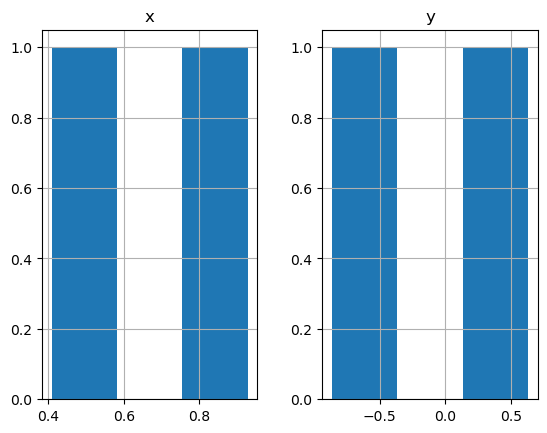

In [12]:
reposition.hist(bins="rice")

array([[<Axes: title={'center': 'prices'}>]], dtype=object)

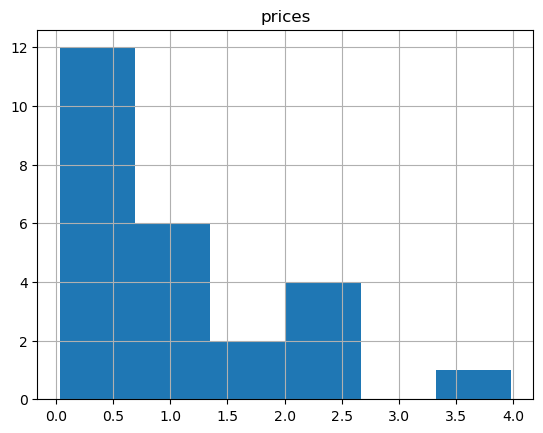

In [13]:
prices.hist(bins="rice")

array([[<Axes: title={'center': 'dispatch'}>]], dtype=object)

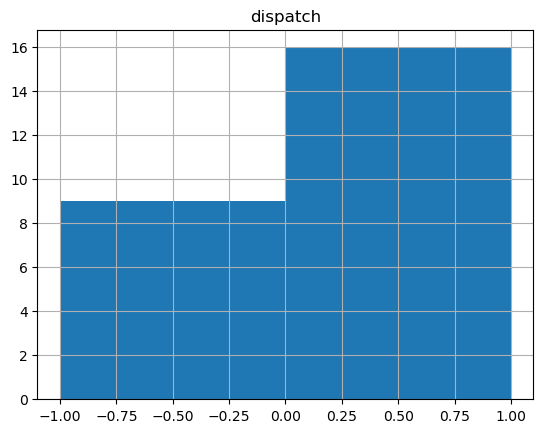

In [14]:
dispatches.hist(bins="rice")

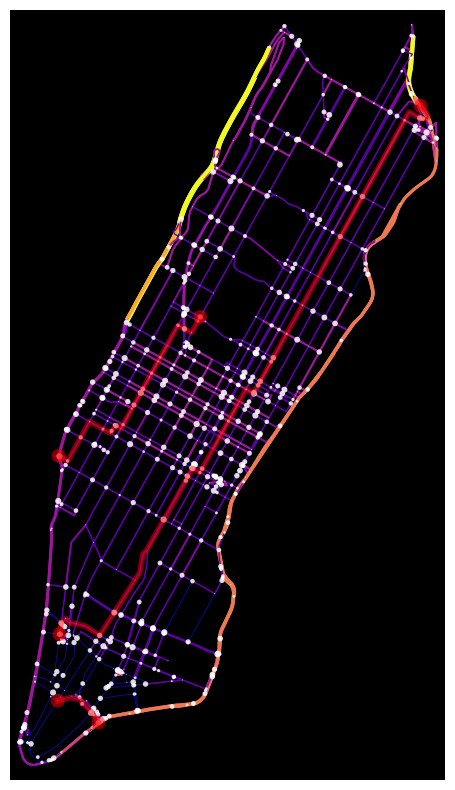

In [15]:
fig, ax = env.render()
fig

In [57]:
obs, reward, term, trunc, info = env.step(action)

In [58]:
RequestDF.default_vals.get("max_wait_time")

15

In [59]:
np.timedelta64(15, "m")

np.timedelta64(15,'m')

In [60]:
filler_requests = RequestDF.generate_empty(num_rows=4)
filler_requests.max_wait_time

0   0 days 00:15:00
1   0 days 00:15:00
2   0 days 00:15:00
3   0 days 00:15:00
Name: max_wait_time, dtype: timedelta64[ns]